**Project:** AI Personal Health & Nutrition Advisor  
**Datasets:** ObesityDataSet, daily_food_nutrition, megaGymDataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Obesity Dataset

In [3]:
obesity = pd.read_csv('..\\data\\raw\\ObesityDataSet_raw_and_data_sinthetic.csv')
print('Shape:', obesity.shape)
print('\nColumns:', obesity.columns.tolist())
obesity.head()

Shape: (2111, 17)

Columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
print('=== Data Types ===')
print(obesity.dtypes)
print('\n=== Missing Values ===')
print(obesity.isnull().sum())
print('\n=== Duplicates ===')
print(f'Duplicated rows: {obesity.duplicated().sum()}')

=== Data Types ===
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

=== Missing Values ===
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC         

=== Target Distribution ===
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


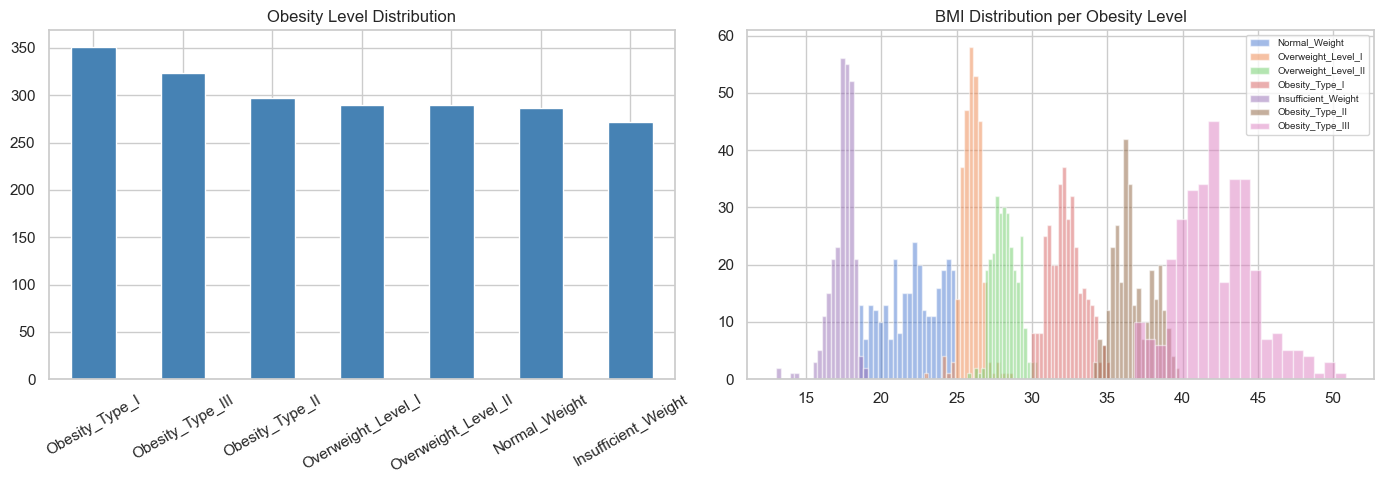

In [5]:
print('=== Target Distribution ===')
print(obesity['NObeyesdad'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
obesity['NObeyesdad'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Obesity Level Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# BMI distribution per class
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)
for label in obesity['NObeyesdad'].unique():
    subset = obesity[obesity['NObeyesdad'] == label]['BMI']
    axes[1].hist(subset, bins=20, alpha=0.5, label=label)
axes[1].set_title('BMI Distribution per Obesity Level')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

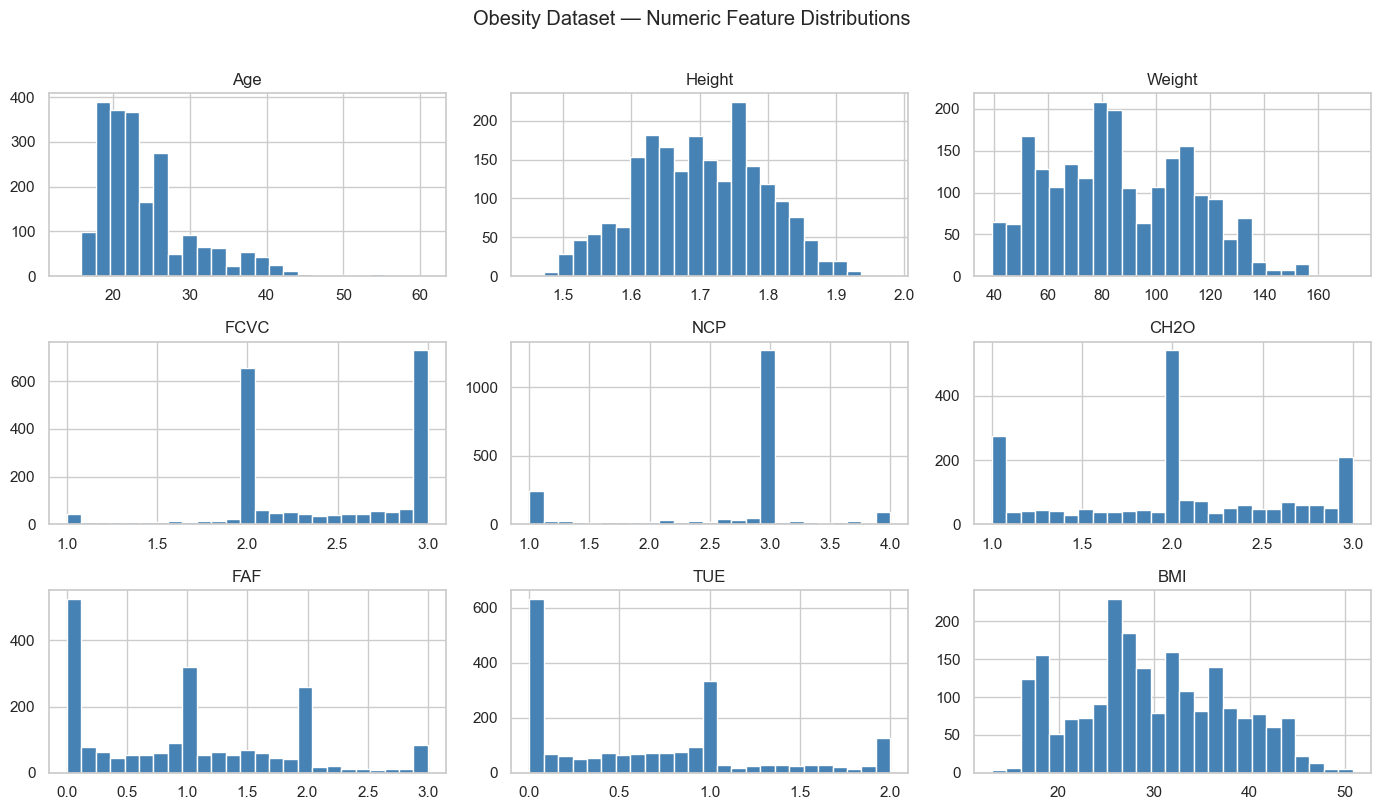

In [6]:
# Numeric feature distributions
num_cols = obesity.select_dtypes(include=np.number).columns.tolist()
obesity[num_cols].hist(bins=25, figsize=(14, 8), edgecolor='white', color='steelblue')
plt.suptitle('Obesity Dataset — Numeric Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

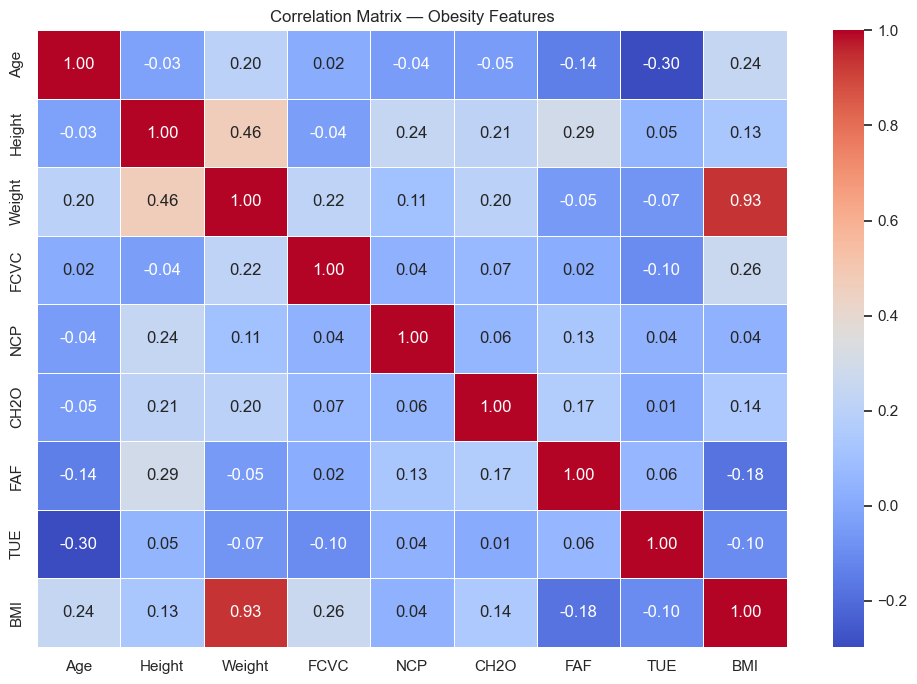

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = obesity[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Obesity Features')
plt.tight_layout()
plt.show()

## 2. Daily Food & Nutrition Dataset

In [15]:
food = pd.read_csv('..\\data\\raw\\daily_food_nutrition_dataset.csv', on_bad_lines='skip')
print('Shape:', food.shape)
print('\nColumns:', food.columns.tolist())
food.head()

Shape: (645, 12)

Columns: ['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)']


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500


In [16]:
print('=== Missing Values ===')
print(food.isnull().sum())
print('\n=== Basic Stats ===')
food.describe()

=== Missing Values ===
Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64

=== Basic Stats ===


,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Water_Intake (ml)
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000
mean,146.294574,6.300620,15.435194,6.469612,1.702481,5.294264,246.331783,20.482171,68.700775
std,139.984360,8.782683,16.349230,8.142916,2.121275,8.537343,308.472431,43.560072,137.077115
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.500000,1.300000,0.200000,0.000000,0.400000,5.000000,0.000000,0.000000
50%,105.000000,2.700000,9.200000,3.000000,1.000000,2.000000,120.000000,0.000000,0.000000
75%,200.000000,7.000000,27.000000,10.000000,3.000000,6.000000,350.000000,25.000000,0.000000
max,680.000000,45.000000,70.000000,40.000000,14.000000,60.000000,1580.000000,450.000000,500.000000


Calorie columns found: ['Calories (kcal)']


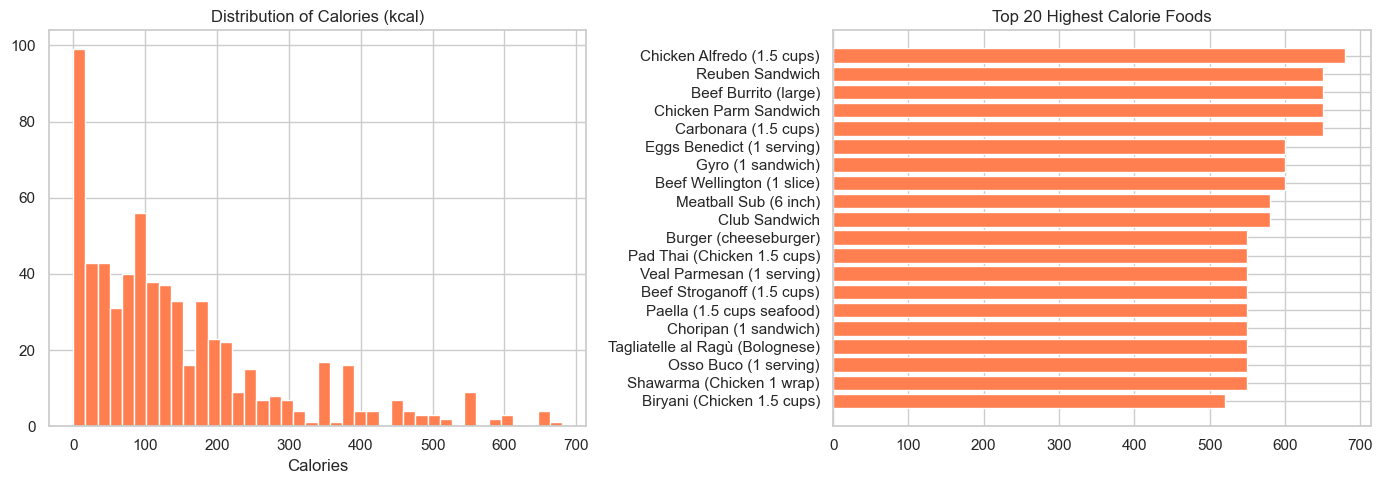

In [17]:
# Calorie distribution
# Identify calorie column (common names)
cal_col = [c for c in food.columns if 'calori' in c.lower() or 'energy' in c.lower() or 'kcal' in c.lower()]
print('Calorie columns found:', cal_col)

if cal_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    food[cal_col[0]].hist(bins=40, ax=axes[0], color='coral', edgecolor='white')
    axes[0].set_title(f'Distribution of {cal_col[0]}')
    axes[0].set_xlabel('Calories')

    # Top 20 highest calorie foods
    food_name_col = [c for c in food.columns if 'food' in c.lower() or 'name' in c.lower() or 'item' in c.lower()]
    if food_name_col:
        top20 = food.nlargest(20, cal_col[0])[[food_name_col[0], cal_col[0]]]
        axes[1].barh(top20[food_name_col[0]], top20[cal_col[0]], color='coral')
        axes[1].set_title('Top 20 Highest Calorie Foods')
        axes[1].invert_yaxis()
    plt.tight_layout()
    plt.show()

Macro columns: ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)']


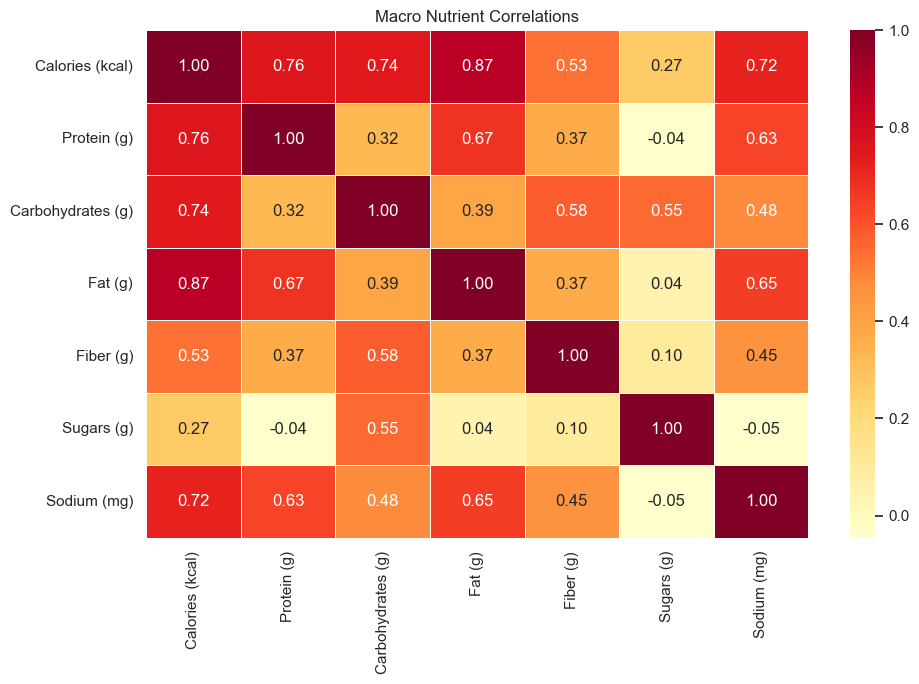

In [18]:
# Macro nutrients correlation
macro_keywords = ['protein', 'carb', 'fat', 'fiber', 'sugar', 'sodium', 'calori', 'energy']
macro_cols = [c for c in food.columns if any(k in c.lower() for k in macro_keywords)]
print('Macro columns:', macro_cols)

if len(macro_cols) > 2:
    plt.figure(figsize=(10, 7))
    sns.heatmap(food[macro_cols].corr(), annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Macro Nutrient Correlations')
    plt.tight_layout()
    plt.show()

## 3. Gym Exercise Dataset

In [19]:
gym = pd.read_csv('..\\data\\raw\\megaGymDataset.csv')
print('Shape:', gym.shape)
print('\nColumns:', gym.columns.tolist())
gym.head()

Shape: (2918, 9)

Columns: ['Unnamed: 0', 'Title', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating', 'RatingDesc']


,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [20]:
print('=== Missing Values ===')
print(gym.isnull().sum())
print('\n=== Unique Values per Categorical Column ===')
cat_cols = gym.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {gym[col].nunique()} unique -> {gym[col].unique()[:10]}')

=== Missing Values ===
Unnamed: 0       0
Title            0
Desc          1550
Type             0
BodyPart         0
Equipment       32
Level            0
Rating        1887
RatingDesc    2056
dtype: int64

=== Unique Values per Categorical Column ===
Title: 2909 unique -> ['Partner plank band row' 'Banded crunch isometric hold'
 'FYR Banded Plank Jack' 'Banded crunch' 'Crunch'
 'Decline band press sit-up' 'FYR2 Banded Frog Pump'
 'Band low-to-high twist' 'Barbell roll-out'
 'Barbell Ab Rollout - On Knees']
Desc: 1050 unique -> ['The partner plank band row is an abdominal exercise where two partners perform single-arm planks while pulling on the opposite ends of an exercise band. This technique can be done for time or reps in any ab-focused workout.'
 'The banded crunch isometric hold is an exercise targeting the abdominal muscles, particularly the rectus abdominis or "six-pack" muscles. The band adds resistance and continuous tension to this popular exercise.'
 'The banded plank jack

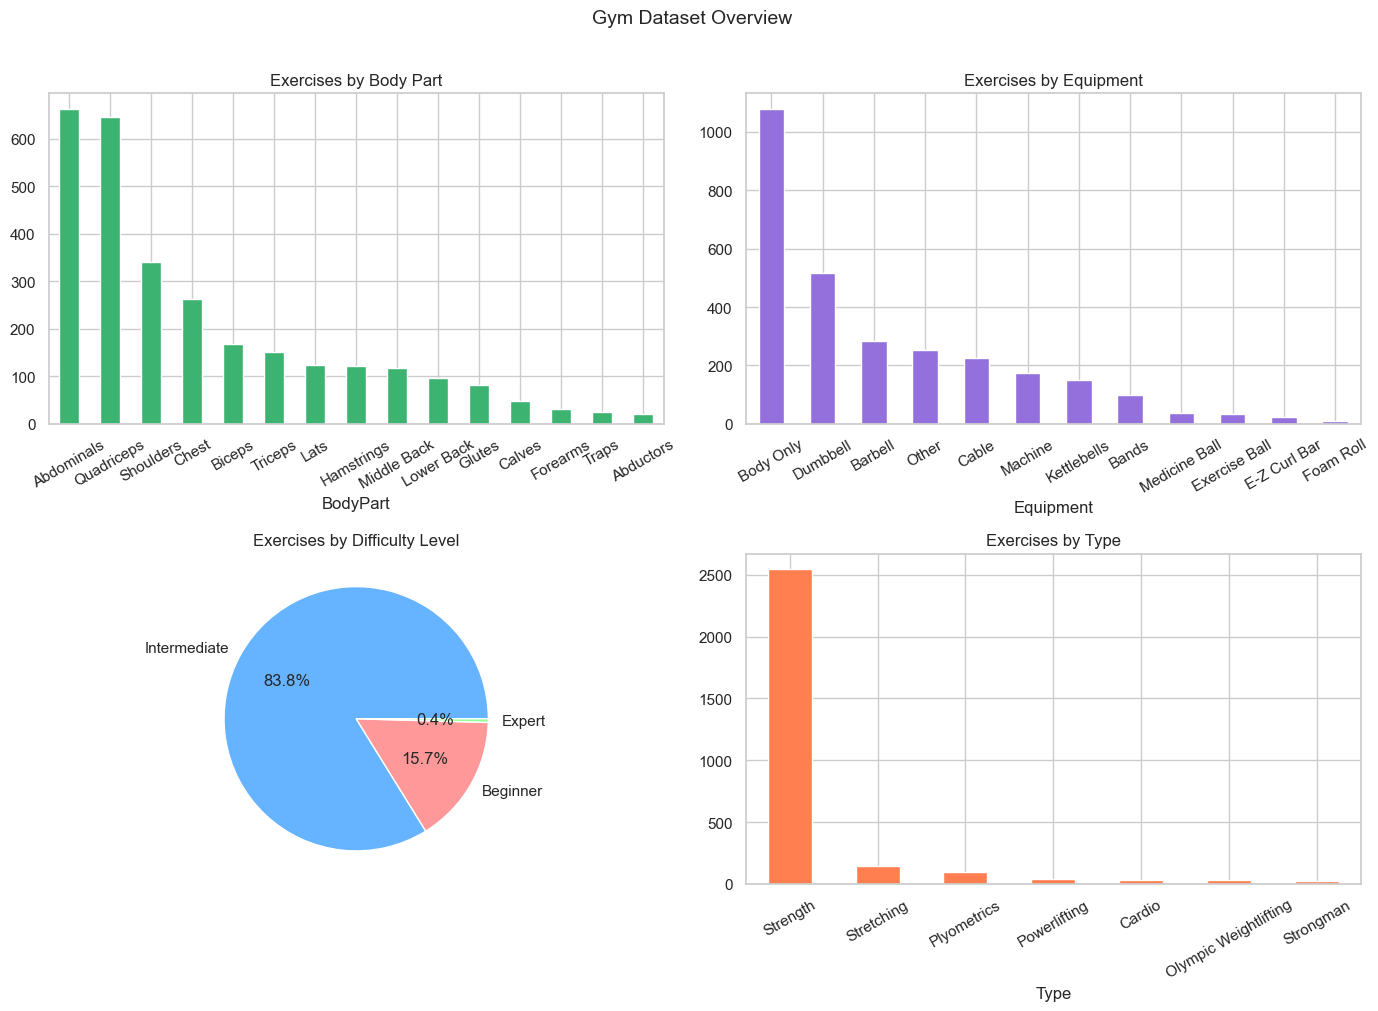

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Body part distribution
if 'BodyPart' in gym.columns:
    gym['BodyPart'].value_counts().head(15).plot(kind='bar', ax=axes[0,0], color='mediumseagreen', edgecolor='white')
    axes[0,0].set_title('Exercises by Body Part')
    axes[0,0].tick_params(axis='x', rotation=30)

# Equipment distribution
if 'Equipment' in gym.columns:
    gym['Equipment'].value_counts().head(15).plot(kind='bar', ax=axes[0,1], color='mediumpurple', edgecolor='white')
    axes[0,1].set_title('Exercises by Equipment')
    axes[0,1].tick_params(axis='x', rotation=30)

# Level distribution
if 'Level' in gym.columns:
    gym['Level'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'])
    axes[1,0].set_title('Exercises by Difficulty Level')
    axes[1,0].set_ylabel('')

# Type distribution
if 'Type' in gym.columns:
    gym['Type'].value_counts().plot(kind='bar', ax=axes[1,1], color='coral', edgecolor='white')
    axes[1,1].set_title('Exercises by Type')
    axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Gym Dataset Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()